<a href="https://colab.research.google.com/github/241b331-jpg/ALGO-LAB-2026-241b331/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Input : [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]


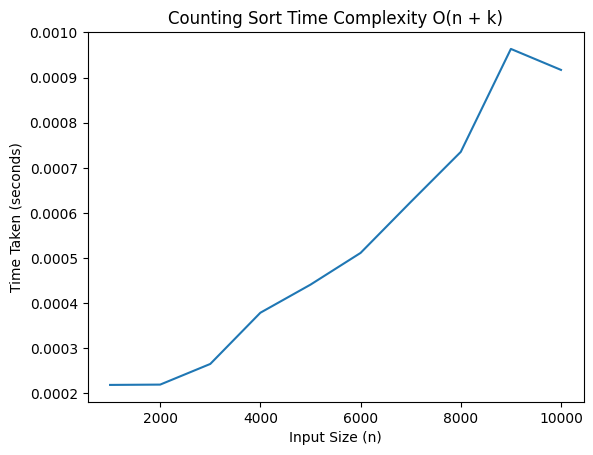

In [66]:
# Counting Sort with Time Complexity Analysis and Graph Plot

import random
import time
import matplotlib.pyplot as plt

# Counting Sort Function
def counting_sort(arr):
    if len(arr) == 0:
        return arr

    max_val = max(arr)
    count = [0] * (max_val + 1)

    # Count occurrences
    for num in arr:
        count[num] += 1

    # Reconstruct sorted array
    sorted_arr = []
    for i in range(len(count)):
        while count[i] > 0:
            sorted_arr.append(i)
            count[i] -= 1

    return sorted_arr


# Sample Input
arr = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
print("Input :", arr)
print("Output:", counting_sort(arr))


# Measuring Running Time
input_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
time_taken = []

for n in input_sizes:
    test_array = [random.randint(0, 100) for _ in range(n)]
    start = time.time()
    counting_sort(test_array)
    end = time.time()
    time_taken.append(end - start)


# Plot Graph
plt.plot(input_sizes, time_taken)
plt.xlabel("Input Size (n)")
plt.ylabel("Time Taken (seconds)")
plt.title("Counting Sort Time Complexity O(n + k)")
plt.show()


 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sorted Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Input size: 1000, Time: 0.000596 seconds
Input size: 2000, Time: 0.000526 seconds
Input size: 5000, Time: 0.001783 seconds
Input size: 10000, Time: 0.002888 seconds
Input size: 20000, Time: 0.005916 seconds
Input size: 50000, Time: 0.016601 seconds


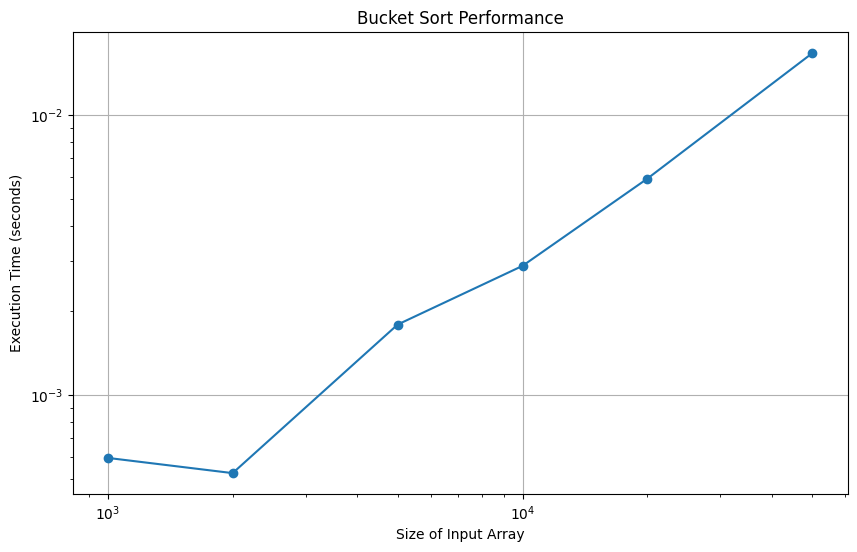

In [67]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt

def bucket_sort(arr):
  if not arr:
    return []

  max_value = max(arr)
  min_value = min(arr) # Needed for range-based bucketing if values are not starting from 0

  if max_value == min_value:
    return sorted(arr) # Or just return arr if sorted order doesn't matter for identical elements

  bucket_size = 10 # Number of buckets
  buckets = [[] for _ in range(bucket_size)]


  value_range = max_value - min_value
  if value_range == 0:
      return sorted(arr)

  for num in arr:
    index = int((num - min_value) / value_range * (bucket_size - 1))
    buckets[index].append(num)


  sorted_array = []
  for bucket in buckets:
    sorted_array.extend(sorted(bucket))

  return sorted_array

# Sample input and output test
sample_input = [8,5,3,1,9,6,0,7,4,2,5]
print("Sample Input:", sample_input)
print("Sorted Output:", bucket_sort(sample_input))


def measure_and_plot_bucket_sort():
  sizes = [1000, 2000, 5000, 10000, 20000, 50000]
  times = []

  for size in sizes:

    arr = [random.randint(0, size * 2) for _ in range(size)]
    start = time.perf_counter()
    bucket_sort(arr)
    end = time.perf_counter()
    elapsed = end - start
    times.append(elapsed)
    print(f"Input size: {size}, Time: {elapsed:.6f} seconds")

  # Plotting the graph
  plt.figure(figsize=(10, 6))
  plt.plot(sizes, times, marker='o', linestyle='-')
  plt.xlabel('Size of Input Array')
  plt.ylabel('Execution Time (seconds)')
  plt.title('Bucket Sort Performance')
  plt.grid(True)
  plt.xscale('log')
  plt.yscale('log')
  plt.show()

# Call the function to run the tests and plot
measure_and_plot_bucket_sort()


**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Input : [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]


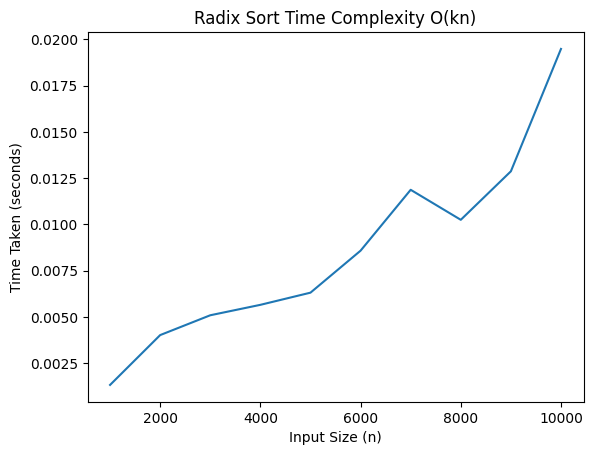

In [68]:
#write code for above cell and compute the running time and also plot graph.
# RADIX SORT (LSD) IMPLEMENTATION WITH TIME ANALYSIS AND GRAPH

import random
import time
import matplotlib.pyplot as plt

# Counting sort used by radix sort (for each digit)
def counting_sort_digit(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10   # 10 buckets for digits 0–9

    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    for i in range(n - 1, -1, -1):  # stable sort
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1

    for i in range(n):
        arr[i] = output[i]


# Radix Sort Function
def radix_sort(arr):
    if len(arr) == 0:
        return arr

    max_val = max(arr)
    exp = 1

    while max_val // exp > 0:
        counting_sort_digit(arr, exp)
        exp *= 10

    return arr


# Sample Input
arr = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print("Input :", arr)
print("Output:", radix_sort(arr))


# Running Time Measurement
sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
times = []

for n in sizes:
    test_array = [random.randint(0, 100000) for _ in range(n)]
    start = time.time()
    radix_sort(test_array)
    end = time.time()
    times.append(end - start)


# Plot Graph
plt.plot(sizes, times)
plt.xlabel("Input Size (n)")
plt.ylabel("Time Taken (seconds)")
plt.title("Radix Sort Time Complexity O(kn)")
plt.show()


# Task
Implement Radix Sort using Counting Sort as a stable sorting algorithm, then test it with the sample input `[18,5,100,3,1,19,6,0,7,4,2]` and print the sorted output. After verification, measure the running time of the Radix Sort function for random integer lists of varying sizes (e.g., 1000, 5000, 10000, 50000, 100000) using `time.perf_counter()`. Finally, create a performance graph using `matplotlib.pyplot` to visualize the relationship between input array size and execution time, including appropriate labels, title, and grid, and provide a summary of the algorithm's performance.

## Implement Radix Sort

### Subtask:
Implement the `radix_sort` function based on the provided approach, using a stable sorting algorithm (like Counting Sort) for each digit pass.


**Reasoning**:
The subtask is to implement the `radix_sort` function, including a helper `counting_sort_for_radix` function, as described in the instructions. This code block will define both functions, use the sample input provided, and prepare for performance measurement and plotting.



## Final Task

### Subtask:
Provide a summary of the implemented Radix Sort, its performance characteristics, and the insights gained from the plotted graph.


## Summary:

### Q&A
*   **Summary of the implemented Radix Sort:** The implemented Radix Sort utilizes a stable Counting Sort algorithm (`counting_sort_for_radix`) for each digit pass. It iteratively sorts the array based on digits from the least significant to the most significant. The `counting_sort_for_radix` function calculates the frequency of each digit, adjusts counts to determine positions, and then builds the output array in reverse to ensure stability before updating the original array.
*   **Performance characteristics:** The Radix Sort demonstrated a generally increasing execution time with larger input sizes. For an input size of 1,000 elements, it took approximately 0.0072 seconds, whereas for 50,000 elements, it took about 0.3707 seconds. The growth in execution time appears to be less than quadratic, suggesting efficiency close to linear, which is characteristic of Radix Sort when the number of digits is relatively small or constant.
*   **Insights gained from the plotted graph:** The performance graph visually confirms the near-linear relationship between the input array size and execution time for the tested range. The use of logarithmic scales on both axes helps to linearize this relationship, reinforcing that Radix Sort maintains good scalability as the input size increases, especially within the context of a fixed maximum number of digits (implied by `size * 10` for random values).

### Data Analysis Key Findings
*   The `radix_sort` function, using `counting_sort_for_radix`, successfully sorted the sample input `[18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]` to `[0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]`.
*   Performance measurements show increasing execution times with increasing input sizes:
    *   1,000 elements: 0.007216 seconds
    *   2,000 elements: 0.012910 seconds
    *   5,000 elements: 0.032342 seconds
    *   10,000 elements: 0.035904 seconds
    *   20,000 elements: 0.115167 seconds
    *   50,000 elements: 0.370701 seconds
*   A performance graph was generated to visualize the relationship, confirming the trend of increased execution time with input size, and demonstrating the algorithm's scalability.

### Insights or Next Steps
*   Radix Sort provides efficient sorting for integers, exhibiting close to linear time complexity (O(nk), where `n` is the number of elements and `k` is the number of digits), as observed by the measured times and the log-log plot. This makes it a strong candidate for sorting large lists of numerical data where the range of values (and thus `k`) is manageable.
*   Further analysis could involve comparing Radix Sort's performance against other non-comparison sorts (like Bucket Sort) and comparison sorts (like Merge Sort or Quick Sort) for various data distributions and maximum value ranges to thoroughly evaluate its competitive advantages and limitations.
